# 01 - Exploration des tracés PDF vectoriels et benchmark du baseline classique

Les 4 tracés sont les vrais fichiers PDF vectoriels natifs générés par Gerber AccuMark
(`data/raw/reference/Tracee1.pdf` à `Tracee4.pdf`). Le texte (nom de pièce, taille, code
modèle) est un calque texte réel positionné — pas une image — donc pas besoin d'OCR.
Le PDF est aussi à l'échelle physique réelle (1:1).

**Objectif de ce notebook :**
1. Rasteriser chaque PDF et inspecter visuellement
2. Extraire le calque texte (noms de pièces + position) avec PyMuPDF
3. Compter le **vrai** nombre de pièces par tracé à partir du texte (vérité terrain fiable)
4. Faire tourner le baseline classique (Canny + approxPolyDP) sur l'image rasterisée
5. Comparer le comptage du baseline classique à la vérité terrain


In [1]:
import sys
print(sys.executable)
import sys
!{sys.executable} -m pip install opencv-python numpy matplotlib pdfplumber pymupdf

c:\Users\MSI\anaconda3\envs\myenv\python.exe


In [2]:
import sys
sys.path.append('../src')

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from acquisition.pdf_loader import rasterize_pdf, extract_text_layer, get_pdf_page_size_cm
from segmentation.classical_baseline import preprocess_classical, find_pieces, calibrate_with_reference_card, draw_result, BaselineResult

REFERENCE_DIR = Path('../data/raw/reference')
pdf_paths = sorted(REFERENCE_DIR.glob('Tracee*.pdf'))
print(f"{len(pdf_paths)} tracés PDF trouvés :")
for p in pdf_paths:
    print(" -", p.name)

4 tracés PDF trouvés :
 - Tracee1.pdf
 - Tracee2.pdf
 - Tracee3.pdf
 - Tracee4.pdf


## 1. Rasterisation et taille physique réelle

In [3]:
images = {}
page_sizes_cm = {}

for pdf_path in pdf_paths:
    name = pdf_path.stem
    img = rasterize_pdf(str(pdf_path), dpi=100)
    w_cm, h_cm = get_pdf_page_size_cm(str(pdf_path))
    images[name] = img
    page_sizes_cm[name] = (w_cm, h_cm)
    print(f"{name:10s} -> image {img.shape[1]}x{img.shape[0]} px | taille physique réelle {w_cm:.1f} x {h_cm:.1f} cm")

Tracee1    -> image 4000x2478 px | taille physique réelle 202.8 x 125.6 cm
Tracee2    -> image 4000x2417 px | taille physique réelle 252.0 x 152.3 cm
Tracee3    -> image 3196x4000 px | taille physique réelle 128.3 x 160.6 cm
Tracee4    -> image 3965x4000 px | taille physique réelle 147.3 x 148.6 cm


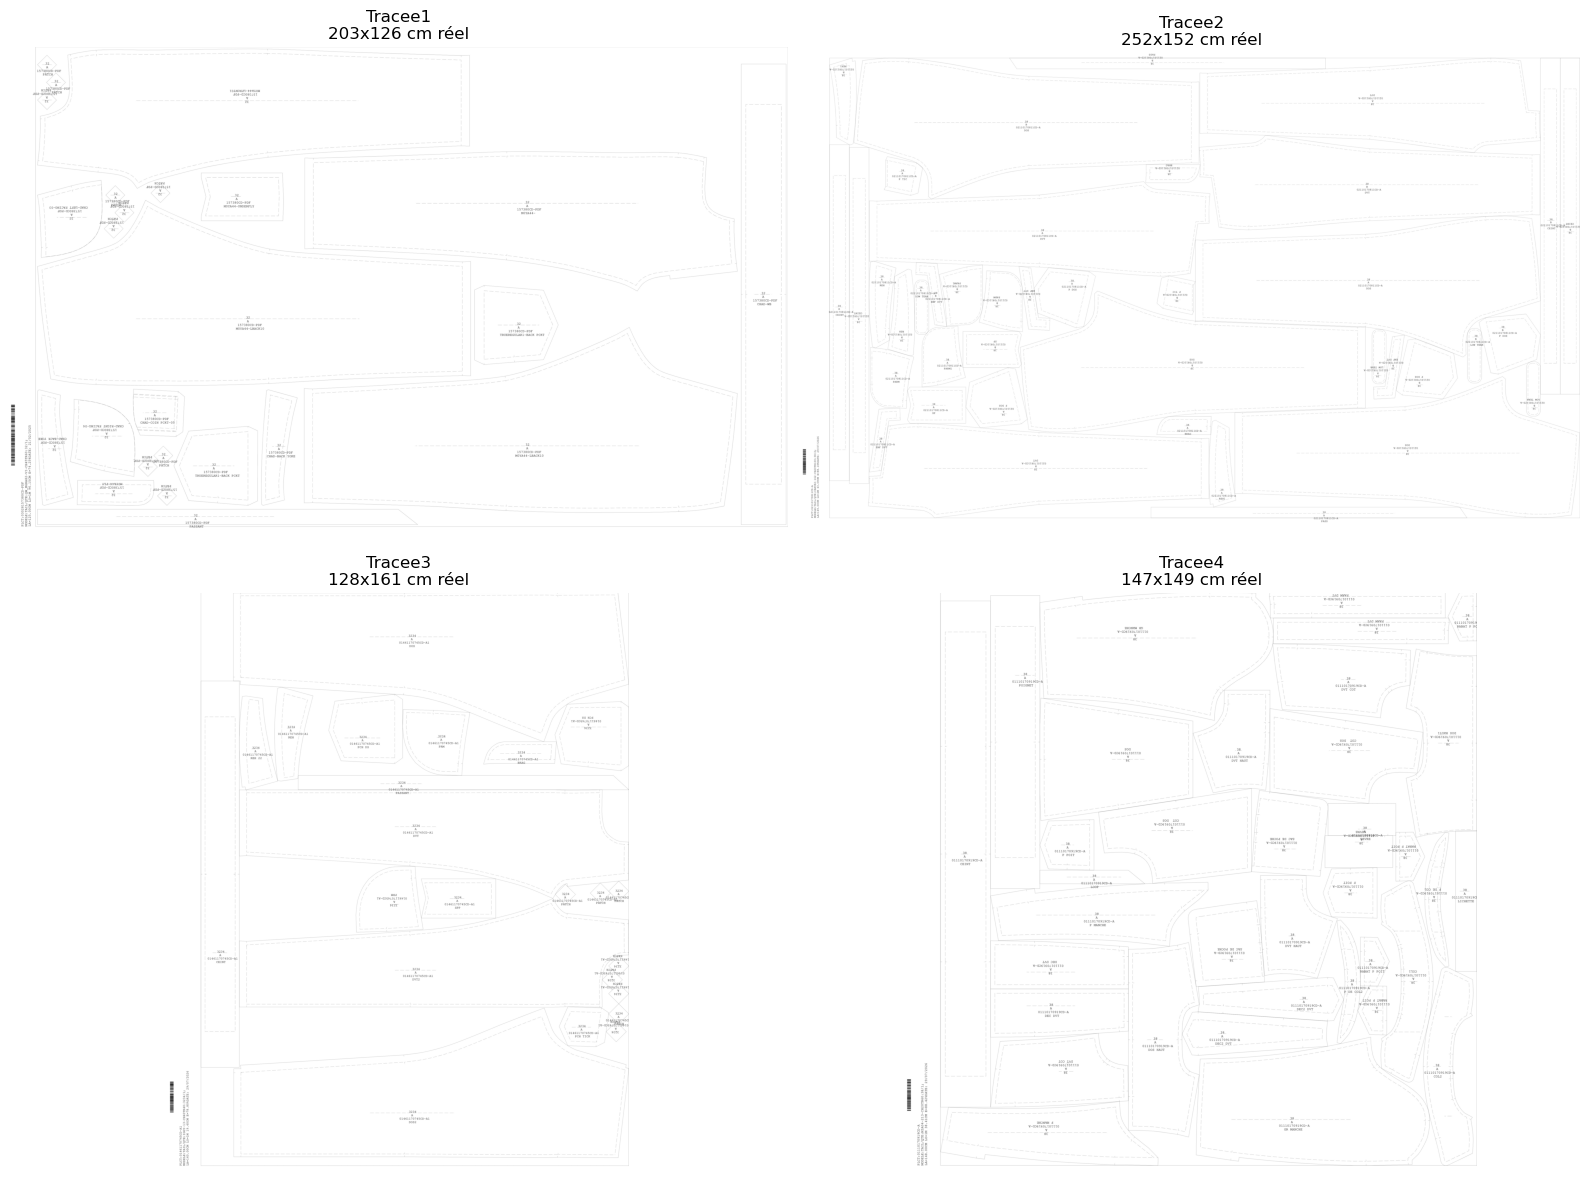

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, (name, img) in zip(axes.ravel(), images.items()):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    w_cm, h_cm = page_sizes_cm[name]
    ax.set_title(f"{name}\n{w_cm:.0f}x{h_cm:.0f} cm réel")
    ax.axis('off')
plt.tight_layout()
plt.savefig('../data/processed/01_apercu_4_tracés_pdf.png', dpi=100)
plt.show()

## 2. Vérité terrain : nombre réel de pièces par tracé (via le texte)

PyMuPDF lit correctement le texte du plan, y compris les libellés pivotés (une partie
des pièces a son nom imprimé à la verticale ou à l'envers pour suivre son orientation
sur le plan — la librairie précédente, pdfplumber, en perdait une bonne partie).

Chaque pièce imprime son propre code modèle (ex. `157380CD-PDF`) une fois : compter les
occurrences de ce code donne donc le vrai nombre de pièces, de façon fiable.

In [5]:
import fitz
from collections import Counter

ground_truth_counts = {}

for pdf_path in pdf_paths:
    name = pdf_path.stem
    doc = fitz.open(str(pdf_path))
    words = doc[0].get_text("words")
    codes = Counter(w[4] for w in words if 'CD' in w[4])
    code, n = codes.most_common(1)[0]
    ground_truth_counts[name] = n
    print(f"{name:10s} -> {n:3d} pièces réelles (code '{code}' répété {n} fois)")

Tracee1    ->  25 pièces réelles (code '157380CD-PDF' répété 25 fois)
Tracee2    ->  40 pièces réelles (code '02110170811CD-A' répété 40 fois)
Tracee3    ->  19 pièces réelles (code '01461170745CD-A1' répété 19 fois)
Tracee4    ->  35 pièces réelles (code '01110170919CD-A' répété 35 fois)


## 3. Baseline classique (Canny + approxPolyDP) sur les images rasterisées

Le filtrage utilise maintenant l'aire physique réelle (cm²) plutôt que des pixels bruts,
et déduplique les contours trait-plein/trait-pointillé (bord de coupe vs marge de
couture) qui, sinon, comptent deux fois la même pièce.

In [6]:
results = {}
for name, img in images.items():
    w_cm, h_cm = page_sizes_cm[name]
    h_px, w_px = img.shape[:2]
    scale_cm_per_px = ((w_cm / w_px) + (h_cm / h_px)) / 2

    edges = preprocess_classical(img)
    pieces = find_pieces(edges, scale_cm_per_px=scale_cm_per_px, min_area_cm2=15.0)
    scale_calib, found = calibrate_with_reference_card(img, pieces)
    result = BaselineResult(image_shape=img.shape, pieces=pieces, scale_cm_per_px=scale_cm_per_px, calibration_found=found)
    results[name] = result

    truth = ground_truth_counts[name]
    print(f"{name:10s} -> {len(pieces):3d} contours détectés (baseline) vs {truth:3d} pièces réelles (texte)")

Tracee1    ->  18 contours détectés (baseline) vs  25 pièces réelles (texte)
Tracee2    ->  70 contours détectés (baseline) vs  40 pièces réelles (texte)
Tracee3    ->  33 contours détectés (baseline) vs  19 pièces réelles (texte)
Tracee4    ->  66 contours détectés (baseline) vs  35 pièces réelles (texte)


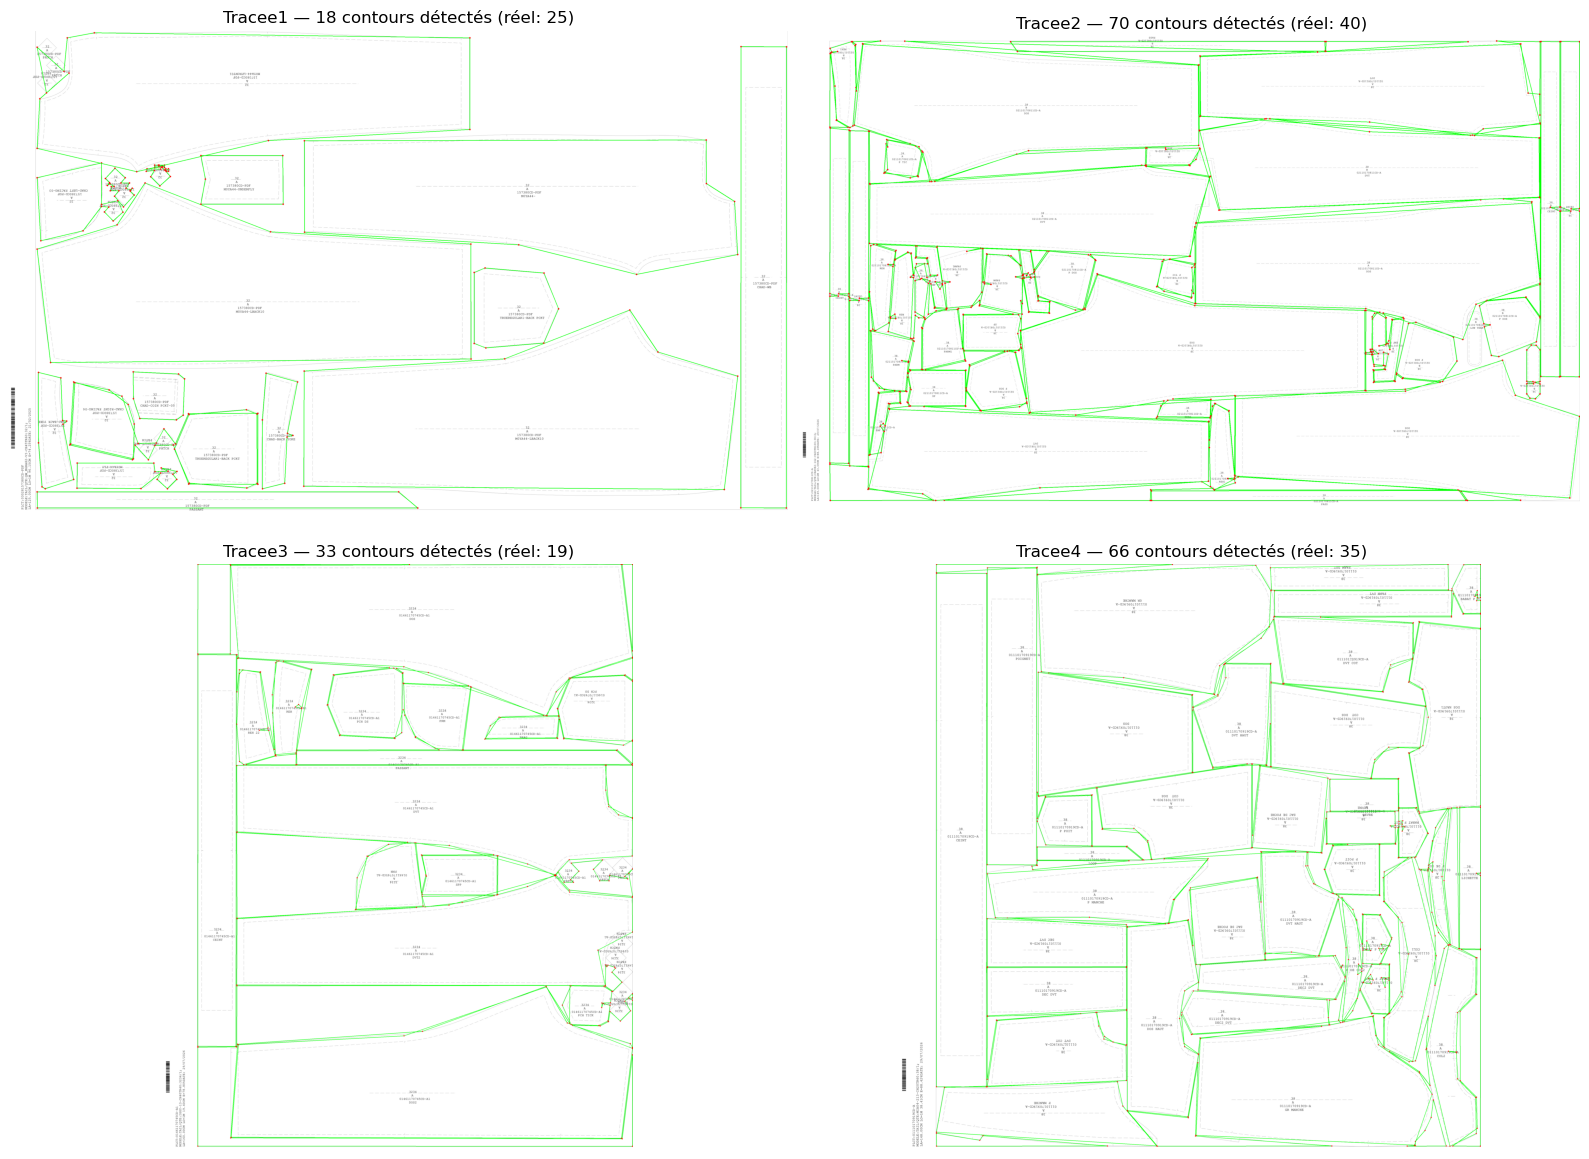

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, (name, img) in zip(axes.ravel(), images.items()):
    result = results[name]
    out = draw_result(img, result)
    out_rgb = cv2.cvtColor(out, cv2.COLOR_BGR2RGB)
    ax.imshow(out_rgb)
    truth = ground_truth_counts[name]
    ax.set_title(f"{name} — {len(result.pieces)} contours détectés (réel: {truth})")
    ax.axis('off')
plt.tight_layout()
plt.savefig('../data/processed/01_baseline_contours.png', dpi=100)
plt.show()

## 4. Résumé et limite connue

Le comptage par contours (Canny + approxPolyDP) reste imprécis et instable d'un tracé
à l'autre, même après filtrage par aire physique et déduplication : chaque plan a un
style de trait et une densité de pièces différents, donc des seuils fixes ne
généralisent pas. C'est exactement la limite qui justifie le passage à une segmentation
apprise (U-Net) en Phase 3, plutôt que de continuer à ajuster des seuils à la main.

**Le comptage par texte (partie 2), lui, est fiable et sert de vérité terrain officielle
pour la suite du projet.**

In [8]:
import json

summary = {
    name: {
        "pieces_detectees_baseline": len(r.pieces),
        "pieces_reelles_texte": ground_truth_counts[name],
        "calibration_carte_trouvee": r.calibration_found,
        "image_shape": r.image_shape,
        "taille_physique_reelle_cm": page_sizes_cm[name],
    }
    for name, r in results.items()
}
print(json.dumps(summary, indent=2, ensure_ascii=False))

with open('../data/results/01_baseline_benchmark.json', 'w') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

{
  "Tracee1": {
    "pieces_detectees_baseline": 18,
    "pieces_reelles_texte": 25,
    "calibration_carte_trouvee": true,
    "image_shape": [
      2478,
      4000,
      3
    ],
    "taille_physique_reelle_cm": [
      202.81392537434897,
      125.63347703721789
    ]
  },
  "Tracee2": {
    "pieces_detectees_baseline": 70,
    "pieces_reelles_texte": 40,
    "calibration_carte_trouvee": true,
    "image_shape": [
      2417,
      4000,
      3
    ],
    "taille_physique_reelle_cm": [
      252.0060993109809,
      152.27029215494792
    ]
  },
  "Tracee3": {
    "pieces_detectees_baseline": 33,
    "pieces_reelles_texte": 19,
    "calibration_carte_trouvee": true,
    "image_shape": [
      4000,
      3196,
      3
    ],
    "taille_physique_reelle_cm": [
      128.3207979329427,
      160.6396693250868
    ]
  },
  "Tracee4": {
    "pieces_detectees_baseline": 66,
    "pieces_reelles_texte": 35,
    "calibration_carte_trouvee": true,
    "image_shape": [
      4000,
     

## Prochaines étapes

1. Commencer l'annotation des points de contour (vertices) pièce par pièce
2. Construire la table de référence des dimensions nominales à partir des 4 tracés
3. Démarrer le développement de la segmentation U-Net
